
# Notebook 03 — Axe A : prédiction du taux de variation de la marge

**Copilote Financier — Groupe Angelotti | Mémoire M2 MIASHS**

Objectif métier (besoins B-A1, B-A2 de `docs/03_besoins_metier.md`) :
détecter les opérations dont la marge dérive par rapport au budget
d'engagement, et expliquer cette dérive par des variables disponibles tôt.

Démarche en deux volets :

1. **Régression** du taux de variation de la marge — moindres carrés
   ordinaires (OLS) écrits à la main puis vérifiés, lecture par le maximum
   de vraisemblance (MLE), descente de gradient, régularisation Ridge/Lasso,
   métriques MSE et R² *(cours : optim.pdf ; modèle_de_régression.pdf ;
   regularization.pdf)* ;
2. **Classification** des opérations « à risque » — fonctions de décision
   linéaires, régression logistique (sigmoïde, log-perte), SVM (perte
   charnière, marge), arbres de décision et forêt aléatoire, softmax
   multiclasse, perceptron multicouche (ReLU), métrique F1
   *(cours : course.pdf ; optim.pdf ; coursClassif-3ArbresDecision.pdf ;
   regularization.pdf)*.

Chaque section précise la notation du cours qu'elle suit : `optim.pdf` note
les paramètres $w$ et les itérés $w^{(k)}$ ; `regularization.pdf` note
$\theta$ ; nous signalons chaque changement (cf. Annexe B de
`docs/reference_cours.md`).


In [1]:
# --- Amorçage : exécution locale ou Google Colab ---
import importlib.util, pathlib, subprocess, sys

DEPOT = "github.com/yzasmin/MemoireM2S2.git"
BRANCHE = "claude/copilote-financier-angelotti-72c614"

racine = pathlib.Path.cwd()
while not (racine / "src" / "nettoyage.py").exists() and racine != racine.parent:
    racine = racine.parent
if not (racine / "src" / "nettoyage.py").exists():   # environnement Colab vierge
    r = subprocess.run(["git", "clone", "-b", BRANCHE, f"https://{DEPOT}"],
                       capture_output=True, text=True)
    if r.returncode != 0:                             # dépôt privé -> token requis
        from getpass import getpass
        token = getpass("Dépôt privé — colle un token GitHub en LECTURE SEULE : ").strip()
        subprocess.run(["git", "clone", "-b", BRANCHE, f"https://{token}@{DEPOT}"],
                       check=True)
    racine = pathlib.Path.cwd() / "MemoireM2S2"
    # N'installe que ce qui manque (Colab a déjà pandas/sklearn/statsmodels)
    for module, paquet in [("openpyxl", "openpyxl"), ("networkx", "networkx"),
                           ("statsmodels", "statsmodels"), ("sklearn", "scikit-learn")]:
        if importlib.util.find_spec(module) is None:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", paquet],
                           check=True)

sys.path.insert(0, str(racine / "src"))
import base_sql

if not base_sql.DB.exists():  # reconstruit data/copilote.db depuis donnéebrut/
    base_sql.construire_base()
DB = base_sql.DB
print("Base prête :", DB)


Base prête : /home/user/MemoireM2S2/data/copilote.db



## 1. Construction du jeu de données et définition de la cible

**Définition de la cible.** Les exports de gestion sont une photo à date :
nous ne disposons pas de l'historique des révisions budgétaires. Nous
estimons donc les dépenses à terminaison poste par poste par la règle de
gestion standard « un dépassement engagé est acquis, le budget restant sera
dépensé » :

$$D^{\mathrm{term}} = \sum_{p \in \text{postes}} \max\big(\text{engagé}_p,\ \text{budget}_p\big),
\qquad M^{\mathrm{term}} = R^{\mathrm{budget}} - D^{\mathrm{term}},$$

$$\text{variation de marge} \;=\; \frac{M^{\mathrm{term}} - M^{\mathrm{budget}}}{|M^{\mathrm{budget}}|} \;\le\; 0 .$$

Cette cible capte le **risque de coûts committé** ; le risque de recettes
(rythme et prix de vente) relève de l'axe B — les deux se rejoignent dans
la plateforme. Périmètre : opérations engagées à au moins 60 % (les
dépenses engagées y sont un bon estimateur des dépenses finales) et de
marge budgétée non triviale (> 50 k€).

**Anti-fuite** *(cours EDA, p. 7)* : les variables explicatives n'utilisent
que le **budget initial** (structure des postes), les **caractéristiques**
de l'opération (agence, commune, taille) et les **signaux commerciaux**
(désistements, délais) — jamais l'engagé ni le facturé, qui définissent la
cible.


In [2]:

import sqlite3
import numpy as np
import pandas as pd

import theme_viz
theme_viz.appliquer()
rng = np.random.default_rng(42)

con = sqlite3.connect(DB)

# Dépenses par poste : budget vs engagé -> dépenses à terminaison
b = pd.read_sql("""
    SELECT id_operation, sens, poste_niv1,
           SUM(budget_ht) AS budget, SUM(engage_ht) AS engage
    FROM budget GROUP BY id_operation, sens, poste_niv1""", con)
dep = b.query("sens == 'D'").copy()
dep["terminaison"] = dep[["budget", "engage"]].max(axis=1)
agg = dep.groupby("id_operation").agg(
    dep_budget=("budget", "sum"), dep_engage=("engage", "sum"),
    dep_terminaison=("terminaison", "sum"))
rec = (b.query("sens == 'R'").groupby("id_operation")["budget"].sum()
       .rename("rec_budget"))
df = agg.join(rec, how="inner")
df["taux_engagement"] = df["dep_engage"] / df["dep_budget"]
df["marge_budget"] = df["rec_budget"] - df["dep_budget"]
df["marge_terminaison"] = df["rec_budget"] - df["dep_terminaison"]
# Périmètre : engagement >= 60 %, marge non triviale, recettes budgétées
# positives (6 opérations sans recettes budgétées — montages atypiques de
# type portage/tranche de coûts — sont écartées : leur « variation de
# marge » n'a pas de sens économique).
df = df[(df["taux_engagement"] >= 0.6) & (df["marge_budget"].abs() > 5e4)
        & (df["rec_budget"] > 0)]
df["variation_marge"] = ((df["marge_terminaison"] - df["marge_budget"])
                         / df["marge_budget"].abs())

# Variables explicatives — structure du budget INITIAL (parts par poste)
parts = (dep.pivot_table(index="id_operation", columns="poste_niv1",
                         values="budget", aggfunc="sum").fillna(0))
parts = parts.div(parts.sum(axis=1), axis=0)
parts.columns = ["part_" + c.lower().replace(" ", "_").replace("/", "_")
                 for c in parts.columns]

# Caractéristiques d'opération + signaux commerciaux + commune
ops = pd.read_sql("""
    SELECT o.id_operation, o.agence, o.activite, o.statut,
           c.population, c.littoral
    FROM operations o LEFT JOIN communes c USING (commune_norm)""", con)
com = pd.read_sql("""
    SELECT id_operation, COUNT(*) AS nb_dossiers, AVG(desiste) AS taux_desistement,
           AVG(prix_vente_ttc) AS prix_moyen
    FROM ventes GROUP BY id_operation""", con)

df = (df.reset_index()
        .merge(parts.reset_index(), on="id_operation")
        .merge(ops, on="id_operation", how="left")
        .merge(com, on="id_operation", how="left"))
df["log_recettes"] = np.log(df["rec_budget"])
df["marge_relative_budget"] = df["marge_budget"] / df["rec_budget"]
df["taux_desistement"] = df["taux_desistement"].fillna(0)
df["nb_dossiers"] = df["nb_dossiers"].fillna(0)
df["littoral"] = df["littoral"].fillna(0)
df["log_population"] = np.log(df["population"].fillna(df["population"].median()))

print(f"Échantillon : {len(df)} opérations mûres (engagement >= 60 %)")
df["variation_marge"].describe().round(3).to_frame().T


Échantillon : 123 opérations mûres (engagement >= 60 %)


,count,mean,std,min,25%,50%,75%,max
variation_marge,123.0,-0.033,0.131,-1.255,-0.024,-0.004,0.0,0.0


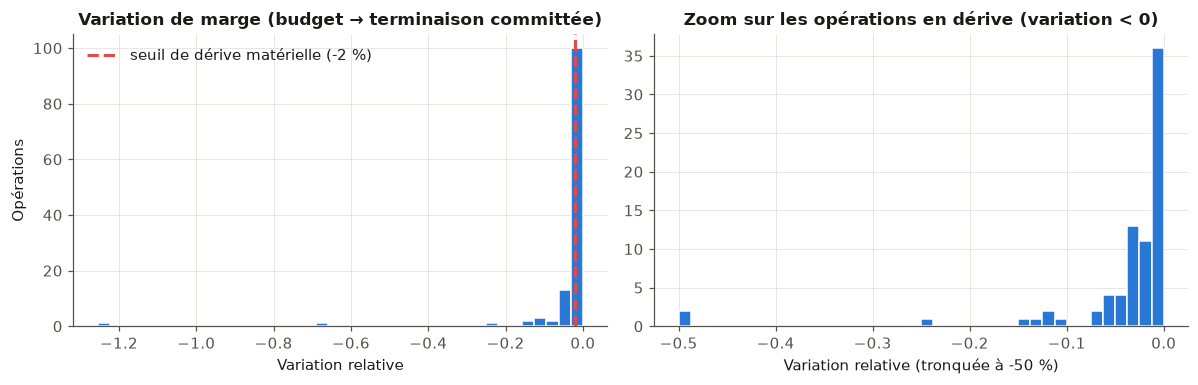

Opérations à risque (dérive < -2 %) : 34 / 123 (28%) — classes déséquilibrées, F1 requis (cours EDA p. 3).


In [3]:

import matplotlib.pyplot as plt

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.hist(df["variation_marge"], bins=40, color=theme_viz.SERIES[0], edgecolor="white")
a1.axvline(-0.02, color=theme_viz.STATUT["risque"], linestyle="--",
           label="seuil de dérive matérielle (-2 %)")
a1.set_title("Variation de marge (budget → terminaison committée)")
a1.set_xlabel("Variation relative"); a1.set_ylabel("Opérations"); a1.legend(frameon=False)

derive = df["variation_marge"].clip(lower=-0.5)
a2.hist(derive[derive < 0], bins=40, color=theme_viz.SERIES[0], edgecolor="white")
a2.set_title("Zoom sur les opérations en dérive (variation < 0)")
a2.set_xlabel("Variation relative (tronquée à -50 %)")
plt.tight_layout(); plt.show()

y_class = (df["variation_marge"] < -0.02).astype(int)   # 1 = « à risque »
print(f"Opérations à risque (dérive < -2 %) : {y_class.sum()} / {len(df)}"
      f" ({y_class.mean():.0%}) — classes déséquilibrées, F1 requis (cours EDA p. 3).")



**Lecture.** La moitié des opérations n'a aucun dépassement engagé
(variation nulle) ; un quart dépasse la « dérive matérielle » de −2 % de la
marge ; quelques cas extrêmes perdent plus de la moitié de la marge
budgétée. Cette structure semi-continue justifie le double traitement :
régression pour quantifier, classification pour alerter.



## 2. Régression par moindres carrés ordinaires (OLS) — théorie du cours

Nous suivons `optim.pdf` (notation $w$, Exemple 2.6, p. 11) : pour des
données $(x_i, y_i)_{i=1}^n$, la fonction de perte est

$$f(w) = \frac{1}{2n}\sum_{i=1}^{n} \big(y_i - w^\top x_i\big)^2,
\qquad \nabla f(w) = \frac{1}{n}\big(X^\top X w - X^\top y\big),
\qquad H_f(w) = \frac{1}{n}X^\top X .$$

Si $X^\top X$ est inversible ($\Leftrightarrow \mathrm{rang}(X) = d$), la
solution en forme close est (Prop. 2.6.1, p. 11-12) :

$$w^* = (X^\top X)^{-1}X^\top y .$$

**Lecture par le maximum de vraisemblance (MLE).** Sous le modèle
$y_i = w^\top x_i + \varepsilon_i$ avec bruit gaussien
$\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$ i.i.d. (la loi normale n'est
formalisée dans aucun des PDF du dépôt — densité
$\varphi(t) = \tfrac{1}{\sigma\sqrt{2\pi}}e^{-t^2/2\sigma^2}$, cf. Azencott,
*Introduction au Machine Learning*), la log-vraisemblance est

$$\log L(w) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n (y_i - w^\top x_i)^2 ,$$

donc **maximiser la vraisemblance équivaut à minimiser la somme des carrés
des résidus** — c'est exactement le principe que le cours de séries
temporelles énonce pour l'estimation ARIMAX (*SeriesTemp_ARIMAX*, slide 3 :
« Maximiser la vraisemblance est équivalent à minimiser $\sum\hat\varepsilon_t^2$ »),
et que `course.pdf` (p. 35) applique côté classification (cross-entropy =
log-vraisemblance négative).


In [4]:

# Variables explicatives (anti-fuite : budget initial + caractéristiques + commercial)
# Les parts de postes somment à 1 : garder les 12 postes + la colonne de biais
# rendrait X^T X singulière (rang(X) < d), violant la condition d'inversibilité
# de la Prop. 2.6.1 d'optim.pdf. On retire donc un poste de référence
# (assurances, le plus petit) — même logique que le drop_first de l'encodage
# one-hot du cours EDA (p. 5).
postes = sorted(c for c in df.columns if c.startswith("part_"))
postes.remove("part_assurances")
# Second garde-fou de rang : les postes quasi constants sur l'échantillon
# (ex. frais de structure, présents sur ~30 opérations du périmètre groupe
# seulement) donnent une colonne standardisée nulle -> Gram singulière.
postes = [p for p in postes if df[p].std() > 1e-3]
print(f"{len(postes)} parts de postes conservées (variance suffisante)")
quanti = postes + ["log_recettes", "marge_relative_budget", "taux_desistement",
                   "nb_dossiers", "littoral", "log_population"]
X_brut = df[quanti].to_numpy(dtype=float)
y = df["variation_marge"].clip(lower=-0.5).to_numpy()   # winsorisation documentée

# Split AVANT toute transformation apprise (cours EDA, p. 8)
from sklearn.model_selection import train_test_split
idx_tr, idx_te = train_test_split(np.arange(len(y)), test_size=0.25,
                                  random_state=42, stratify=y_class)
mu, sd = X_brut[idx_tr].mean(0), X_brut[idx_tr].std(0)
sd[sd == 0] = 1.0
Xs = (X_brut - mu) / sd                              # standardisation fittée sur train
X = np.hstack([np.ones((len(y), 1)), Xs])            # colonne de 1 = biais b
Xtr, ytr, Xte, yte = X[idx_tr], y[idx_tr], X[idx_te], y[idx_te]

# OLS en forme close : w* = (X^T X)^{-1} X^T y   (optim.pdf, Prop. 2.6.1)
w_etoile = np.linalg.solve(Xtr.T @ Xtr, Xtr.T @ ytr)

# Vérification avec scikit-learn
from sklearn.linear_model import LinearRegression
lr = LinearRegression(fit_intercept=False).fit(Xtr, ytr)
print(f"max |w*_manuel - w*_sklearn| = {np.abs(w_etoile - lr.coef_).max():.2e}")

# Métriques du cours modèle_de_régression p. 3 : MSE = (1/n)Σ(y-ŷ)², R² = 1 - Σ(y-ŷ)²/Σ(y-ȳ)²
def mse(y, yh):
    return float(np.mean((y - yh) ** 2))
def r2(y, yh):
    return float(1 - np.sum((y - yh) ** 2) / np.sum((y - y.mean()) ** 2))

for nom, Xa, ya in [("train", Xtr, ytr), ("test ", Xte, yte)]:
    yh = Xa @ w_etoile
    print(f"OLS {nom} : MSE = {mse(ya, yh):.5f} | R² = {r2(ya, yh):+.3f}")


10 parts de postes conservées (variance suffisante)


max |w*_manuel - w*_sklearn| = 2.72e-12
OLS train : MSE = 0.00329 | R² = +0.094
OLS test  : MSE = 0.00779 | R² = +0.077



## 3. Descente de gradient écrite à la main *(optim.pdf, chap. 3)*

L'algorithme 3.1 (p. 16) itère
$w^{(k+1)} = w^{(k)} - \alpha_k \nabla f\big(w^{(k)}\big)$, soit pour les
moindres carrés (Exemple 3.5, p. 19) :

$$w^{(k+1)} = w^{(k)} - \frac{\alpha}{n}X^\top\big(Xw^{(k)} - y\big).$$

Le théorème 3.4 (p. 19) garantit, pour $f$ convexe $L$-lisse et le pas
$\alpha = \frac{1}{L}$, la convergence en $\mathcal{O}(1/k)$ :
$f(w^{(k)}) - f(w^*) \le \frac{L\|w^{(0)} - w^*\|^2}{2k}$. Ici
$L = \lambda_{\max}\big(\tfrac{1}{n}X^\top X\big)$ : la **plus grande valeur
propre** de la Hessienne — les valeurs propres, revues au notebook 02 pour
la PCA, gouvernent aussi la vitesse d'optimisation.


L = λ_max(H) = 4.491 -> pas α = 1/L = 0.223


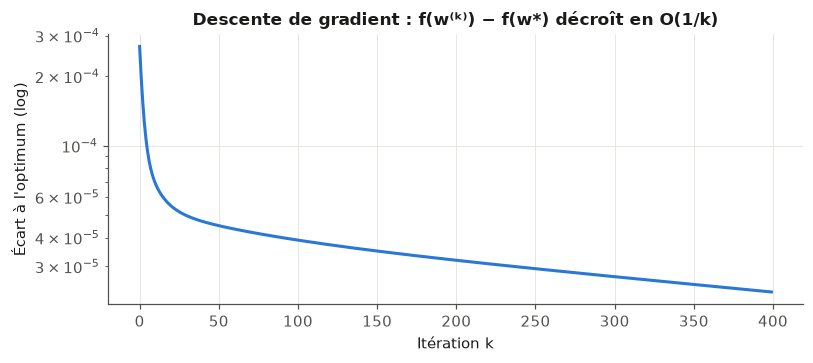

‖w_GD − w*‖ après 400 itérations : 0.1452


In [5]:

n_tr = len(ytr)
H = Xtr.T @ Xtr / n_tr                      # Hessienne (optim.pdf p. 11)
valeurs_propres = np.linalg.eigvalsh(H)     # spectre de H
L = float(valeurs_propres.max())
alpha = 1.0 / L                             # pas 1/L du théorème 3.4
print(f"L = λ_max(H) = {L:.3f} -> pas α = 1/L = {alpha:.3f}")

w = np.zeros(Xtr.shape[1])
historique = []
for k in range(400):
    grad = Xtr.T @ (Xtr @ w - ytr) / n_tr   # ∇f(w) = (1/n)(X^T X w - X^T y)
    w = w - alpha * grad
    historique.append(mse(ytr, Xtr @ w) / 2)

f_etoile = mse(ytr, Xtr @ w_etoile) / 2
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(np.array(historique) - f_etoile, color=theme_viz.SERIES[0])
ax.set_yscale("log")
ax.set_title("Descente de gradient : f(w⁽ᵏ⁾) − f(w*) décroît en O(1/k)")
ax.set_xlabel("Itération k"); ax.set_ylabel("Écart à l'optimum (log)")
plt.tight_layout(); plt.show()
print(f"‖w_GD − w*‖ après 400 itérations : {np.linalg.norm(w - w_etoile):.4f}")



## 4. Régularisation Ridge et Lasso *(optim.pdf p. 12 ; regularization.pdf p. 24-31)*

Avec $n = 129$ opérations et $d \approx 18$ variables corrélées entre elles
(les parts de postes somment à 1), l'OLS est instable : cas d'usage typique
de Ridge (*regularization.pdf*, guide p. 33 : « multicolinéarité, stabilité
numérique requise »).

Attention aux **deux écritures du cours** (Annexe B de la référence) :
`optim.pdf` (Prop. 2.6.2, p. 12) normalise la perte par $\tfrac{1}{2n}$ et
obtient $w^*_\lambda = (X^\top X + n\lambda I_d)^{-1}X^\top y$ — noter le
facteur $n$ — tandis que `regularization.pdf` (p. 25) écrit
$\hat\theta_{\mathrm{Ridge}} = (X^\top X + \lambda I)^{-1}X^\top y$. Les deux
coïncident pour $\lambda_{\mathrm{reg}} = n\,\lambda_{\mathrm{optim}}$ ;
nous vérifions numériquement. Le choix de $\lambda$ suit la procédure de
validation croisée du cours (*regularization.pdf*, p. 31 :
$\hat\lambda = \arg\min_k \mathrm{CV}(\lambda_k)$ sur une grille
`np.logspace`).


In [6]:

lam = 0.1
d_ = Xtr.shape[1]
w_optim = np.linalg.solve(Xtr.T @ Xtr + n_tr * lam * np.eye(d_), Xtr.T @ ytr)
w_regul = np.linalg.solve(Xtr.T @ Xtr + (n_tr * lam) * np.eye(d_), Xtr.T @ ytr)
print(f"Écritures optim.pdf vs regularization.pdf (λ_reg = n·λ_optim) : "
      f"max écart = {np.abs(w_optim - w_regul).max():.2e}")

from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)
grille_ridge = GridSearchCV(Ridge(), {"alpha": np.logspace(-4, 4, 50)},
                            cv=cv, scoring="neg_mean_squared_error").fit(Xtr, ytr)
grille_lasso = GridSearchCV(Lasso(max_iter=50000), {"alpha": np.logspace(-4, 1, 50)},
                            cv=cv, scoring="neg_mean_squared_error").fit(Xtr, ytr)

resultats = []
for nom, modele in [("OLS", lr), ("Ridge", grille_ridge.best_estimator_),
                    ("Lasso", grille_lasso.best_estimator_)]:
    modele.fit(Xtr, ytr)
    resultats.append({"modèle": nom,
                      "λ retenu (CV)": getattr(modele, "alpha", "—"),
                      "MSE test": round(mse(yte, modele.predict(Xte)), 5),
                      "R² test": round(r2(yte, modele.predict(Xte)), 3),
                      "coefficients non nuls": int(np.sum(np.abs(modele.coef_) > 1e-8))})
pd.DataFrame(resultats)


Écritures optim.pdf vs regularization.pdf (λ_reg = n·λ_optim) : max écart = 0.00e+00


,modèle,λ retenu (CV),MSE test,R² test,coefficients non nuls
0,OLS,—,0.00779,0.077,17
1,Ridge,10000.0,0.00867,-0.028,16
2,Lasso,0.013895,0.00869,-0.030,0


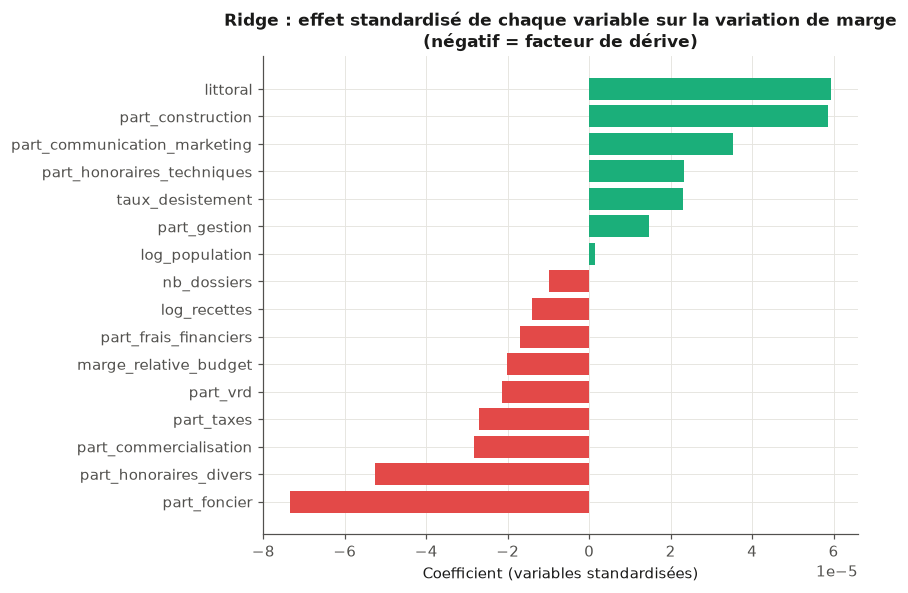

In [7]:

# Quels postes budgétaires expliquent la dérive ? (besoin B-A2, interprétabilité)
noms = ["biais"] + quanti
meilleur = grille_ridge.best_estimator_
coefs = pd.Series(meilleur.coef_[1:], index=noms[1:]).sort_values()
fig, ax = plt.subplots(figsize=(8, 5.5))
couleurs = [theme_viz.STATUT["risque"] if v < 0 else theme_viz.SERIES[1]
            for v in coefs.to_numpy()]
ax.barh(coefs.index, coefs.to_numpy(), color=couleurs)
ax.set_title("Ridge : effet standardisé de chaque variable sur la variation de marge\n"
             "(négatif = facteur de dérive)")
ax.set_xlabel("Coefficient (variables standardisées)")
plt.tight_layout(); plt.show()



**Lecture.** Les coefficients (sur variables standardisées, donc
comparables) désignent les facteurs structurels de dérive — typiquement le
poids des postes techniques (VRD, construction) et le taux de désistement,
tandis qu'une marge relative budgétée confortable protège. Le R² test
modeste est un résultat honnête : la moitié de l'échantillon est à
variation nulle et les dérives extrêmes tiennent à des aléas (contentieux,
géotechnique) absents des données — c'est précisément pourquoi l'axe A
bascule maintenant en **classification** du risque.



## 5. Classification du risque — fonctions de décision linéaires

Nous passons au cadre de `course.pdf` : étiquettes $y \in \{0,1\}$ (« à
risque » = 1 si dérive < −2 %), classe d'hypothèses des **hyperplans**
$\mathcal{H} = \{x \mapsto \mathbb{1}_{w^\top x \ge b}\}$ dont la dimension
de Vapnik-Chervonenkis vaut $d+1$ (p. 24). L'ERM sur la perte 0-1 étant
NP-difficile (p. 32), le cours lui substitue des **pertes de substitution
calibrées** (p. 37-42) ; nous en utilisons deux :

| Perte | $\varphi(t)$ | Modèle |
|---|---|---|
| Logistique | $\log(1+e^{-t})$ | Régression logistique |
| Charnière | $\max(0, 1-t)$ | SVM |

**Régression logistique.** Avec la convention $y \in \{-1,+1\}$ du cours
(p. 33), la log-perte est $\ell_{\log}(y, f(x)) = \log(1+e^{-y f(x)})$ ;
avec $\tilde y \in \{0,1\}$ et la **sigmoïde** $\sigma(t) = \frac{1}{1+e^{-t}}$
(propriétés p. 34 : $1-\sigma(t) = \sigma(-t)$), elle équivaut à la
**cross-entropy** $\ell_{CE}(\tilde y, f(x)) = -\tilde y\log\sigma(f(x)) -
(1-\tilde y)\log(1-\sigma(f(x)))$ (équivalence démontrée p. 35), qui est la
log-vraisemblance négative du modèle $P(Y=1\mid X=x) = \sigma(f(x))$ —
second visage du MLE dans ce notebook. `optim.pdf` (Exemple 2.7, p. 13)
fournit l'objectif $f(w) = \frac{1}{n}\sum\log(1+\exp(-y_i w^\top x_i))$,
convexe, sans forme close : nous le minimisons par descente de gradient,
avec $\nabla f(w) = -\frac{1}{n}\sum_i y_i\,\sigma(-y_i w^\top x_i)\,x_i$.


In [8]:

ycl = y_class.to_numpy()
ypm = 2 * ycl - 1                                # convention y ∈ {-1,+1} (course.pdf p. 33)
Xtr_c, Xte_c = X[idx_tr], X[idx_te]
ytr_c, yte_c = ycl[idx_tr], ycl[idx_te]
ytr_pm = ypm[idx_tr]

def sigma(t):                                    # σ(t) = 1/(1+e^{-t})
    return 1.0 / (1.0 + np.exp(-t))

def log_perte(w, X_, y_pm):                      # f(w) = (1/n)Σ log(1+exp(-y w^T x))
    return float(np.mean(np.log1p(np.exp(-y_pm * (X_ @ w)))))

w_log = np.zeros(Xtr_c.shape[1])
trace = []
for k in range(3000):
    marges = ytr_pm * (Xtr_c @ w_log)
    grad = -(Xtr_c * (ytr_pm * sigma(-marges))[:, None]).mean(axis=0)
    w_log -= 0.5 * grad
    trace.append(log_perte(w_log, Xtr_c, ytr_pm))

from sklearn.linear_model import LogisticRegression
logit_sk = LogisticRegression(penalty=None, fit_intercept=False,
                              max_iter=5000).fit(Xtr_c, ytr_c)
print(f"log-perte finale (GD maison)  : {trace[-1]:.4f}")
print(f"log-perte sklearn (sans pénalité) : "
      f"{log_perte(logit_sk.coef_.ravel(), Xtr_c, ytr_pm):.4f}")
ecart_perte = abs(trace[-1] - log_perte(logit_sk.coef_.ravel(), Xtr_c, ytr_pm))
print(f"écart de log-perte entre les deux : {ecart_perte:.4f}")
print("NB : les POIDS eux-mêmes divergent fortement — sans pénalité et avec des"
      "\ndirections quasi séparantes, l'objectif devient plat et les poids peuvent"
      "\ncroître indéfiniment (optim.pdf p. 13 : pas de forme close ; la perte, elle,"
      "\nconverge). C'est un argument de plus pour la régularisation L2 qui suit.")


log-perte finale (GD maison)  : 0.4992
log-perte sklearn (sans pénalité) : 0.4964
écart de log-perte entre les deux : 0.0028
NB : les POIDS eux-mêmes divergent fortement — sans pénalité et avec des
directions quasi séparantes, l'objectif devient plat et les poids peuvent
croître indéfiniment (optim.pdf p. 13 : pas de forme close ; la perte, elle,
converge). C'est un argument de plus pour la régularisation L2 qui suit.


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(



### Métriques : précision, rappel, F1

Le cours EDA impose le F1 pour les classes déséquilibrées (p. 3, métrique
de la checklist métier). Formules (absentes des PDF, définition standard) :
$\mathrm{P} = \frac{VP}{VP+FP}$, $\mathrm{R} = \frac{VP}{VP+FN}$,
$F_1 = \frac{2\,\mathrm{P}\,\mathrm{R}}{\mathrm{P}+\mathrm{R}}$ — moyenne
harmonique, sévère quand l'un des deux est faible. La **log-perte** sert de
critère d'entraînement, le **F1** de critère de décision métier : rater une
opération en dérive (FN) coûte plus cher qu'une fausse alerte (FP).


In [9]:

from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             log_loss)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Xq = df[quanti].to_numpy(dtype=float)   # pipelines sklearn : scaler DANS la CV (anti-fuite)

modeles = {
    "Baseline (classe majoritaire)": None,
    "Logistique (L2)": make_pipeline(StandardScaler(),
                                     LogisticRegression(max_iter=5000, class_weight="balanced")),
}
scores = {}
base = np.zeros(len(ycl))
scores["Baseline (classe majoritaire)"] = f1_score(ycl, base, zero_division=0)
f1_cv = cross_val_score(modeles["Logistique (L2)"], Xq, ycl, cv=cv5, scoring="f1")
scores["Logistique (L2)"] = f1_cv.mean()
print(f"F1 baseline (tout « sain »)     : {scores['Baseline (classe majoritaire)']:.3f}")
print(f"F1 logistique (CV 5 plis)       : {f1_cv.mean():.3f} ± {f1_cv.std():.3f}")

pipe_logit = modeles["Logistique (L2)"].fit(Xq[idx_tr], ytr_c)
yh = pipe_logit.predict(Xq[idx_te])
print("\nMatrice de confusion (test) :\n",
      confusion_matrix(yte_c, yh))
print(classification_report(yte_c, yh, target_names=["saine", "à risque"],
                            zero_division=0))


F1 baseline (tout « sain »)     : 0.000
F1 logistique (CV 5 plis)       : 0.283 ± 0.185

Matrice de confusion (test) :
 [[17  5]
 [ 5  4]]
              precision    recall  f1-score   support

       saine       0.77      0.77      0.77        22
    à risque       0.44      0.44      0.44         9

    accuracy                           0.68        31
   macro avg       0.61      0.61      0.61        31
weighted avg       0.68      0.68      0.68        31




## 6. SVM — perte charnière et marge *(optim.pdf p. 11 ; course.pdf p. 25-26)*

`optim.pdf` (Exemple 2.5.2, p. 11) donne l'objectif SVM par la **perte
charnière** $f(w) = \sum_{i=1}^n \max(0,\ 1 - y_i(w^\top x_i + b))$,
convexe. `course.pdf` (p. 25) définit le **classifieur à marge** :
$h_{w,b}(x) = \mathrm{sgn}(w^\top x - b)$ sépare avec marge $\gamma$ si
$Y_i(w^\top X_i - b) \ge \gamma$ pour tout $i$, et le théorème de Vapnik
(3.4, p. 25-26) borne $\mathrm{VCdim}(\mathcal{H}_\gamma) \le
\lfloor R^2/\gamma^2\rfloor$ : « la dimension VC dépend de la marge et non
de la dimension ambiante » — justification théorique de la recherche de
marge maximale. La forme duale (multiplicateurs de Lagrange $\alpha_i$,
vecteurs supports ; absente des PDF, cf. Boyd & Vandenberghe, *Convex
Optimization*) est utilisée par `sklearn.svm.SVC` ; le notebook 05 dérive
un lagrangien complet sur le problème de prix.


In [10]:

from sklearn.svm import SVC, LinearSVC

svm_lin = make_pipeline(StandardScaler(),
                        LinearSVC(class_weight="balanced", max_iter=20000))
svm_rbf = make_pipeline(StandardScaler(),
                        SVC(kernel="rbf", class_weight="balanced", gamma="scale"))
for nom, mdl in [("SVM linéaire (charnière)", svm_lin), ("SVM noyau RBF", svm_rbf)]:
    f1_cv = cross_val_score(mdl, Xq, ycl, cv=cv5, scoring="f1")
    scores[nom] = f1_cv.mean()
    print(f"F1 {nom:26s}: {f1_cv.mean():.3f} ± {f1_cv.std():.3f}")

svm_rbf.fit(Xq[idx_tr], ytr_c)
n_sv = svm_rbf.named_steps["svc"].n_support_
print(f"\nVecteurs supports (train, n={len(idx_tr)}) : {n_sv.sum()} "
      f"({n_sv[0]} sains, {n_sv[1]} à risque) — seuls eux définissent la frontière.")


F1 SVM linéaire (charnière)  : 0.303 ± 0.189
F1 SVM noyau RBF             : 0.257 ± 0.074

Vecteurs supports (train, n=92) : 85 (60 sains, 25 à risque) — seuls eux définissent la frontière.



## 7. Arbres de décision et forêt aléatoire *(coursClassif-3ArbresDecision ; regularization.pdf)*

L'arbre CART (slides 4-6) partitionne l'espace par frontières orthogonales
aux axes, en maximisant à chaque nœud le **gain d'information** (slide 15)
$\mathcal{IG}(R_l, R_m) = \mathcal{I}(R) - \frac{n_l}{n}\mathcal{I}(R_l) -
\frac{n_m}{n}\mathcal{I}(R_m)$ avec pour impureté $\mathcal{I}$ le critère
de **Gini** $\mathcal{I}_G(R) = \sum_k p_k(1-p_k)$ ou l'**entropie**
$\mathcal{I}_{\mathcal{E}}(R) = -\sum_k p_k\log_2 p_k$ (slide 16). La
profondeur est choisie par validation croisée (stratégie n°1, slide 19).
Les arbres étant des apprenants faibles (slide 21), on agrège : **forêt
aléatoire** = bagging + sélection de $m = \sqrt{d}$ variables par nœud
(*regularization.pdf*, Algorithme 4.2 et règle p. 11), avec l'erreur
**out-of-bag** comme validation gratuite (Déf. 4.6, p. 9 : chaque bootstrap
laisse $\approx 1/e \approx 36{,}8\,\%$ des points de côté).


Profondeur retenue par CV : 4 | F1 CV = 0.340


F1 forêt (CV 5 plis) : 0.306 ± 0.069 | score OOB (exactitude) : 0.691


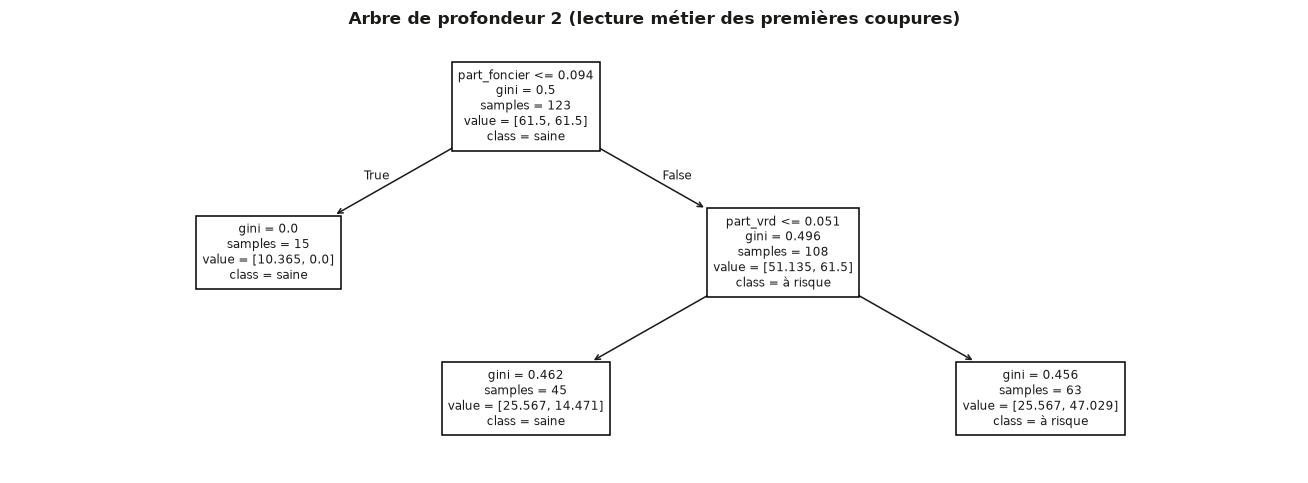

Importances de la forêt (top 8) :
part_foncier                  0.112
marge_relative_budget         0.110
part_vrd                      0.108
log_recettes                  0.096
part_construction             0.086
part_gestion                  0.085
nb_dossiers                   0.080
part_honoraires_techniques    0.075


In [11]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

prof = GridSearchCV(DecisionTreeClassifier(class_weight="balanced", random_state=0),
                    {"max_depth": [2, 3, 4, 5, 6]}, cv=cv5, scoring="f1").fit(Xq, ycl)
arbre = prof.best_estimator_
scores["Arbre CART"] = prof.best_score_
print(f"Profondeur retenue par CV : {prof.best_params_['max_depth']} "
      f"| F1 CV = {prof.best_score_:.3f}")

foret = RandomForestClassifier(n_estimators=500, max_features="sqrt",  # m = √d (p. 11)
                               class_weight="balanced", oob_score=True,
                               random_state=0).fit(Xq, ycl)
f1_rf = cross_val_score(RandomForestClassifier(
    n_estimators=500, max_features="sqrt", class_weight="balanced", random_state=0),
    Xq, ycl, cv=cv5, scoring="f1")
scores["Forêt aléatoire"] = f1_rf.mean()
print(f"F1 forêt (CV 5 plis) : {f1_rf.mean():.3f} ± {f1_rf.std():.3f} "
      f"| score OOB (exactitude) : {foret.oob_score_:.3f}")

fig, ax = plt.subplots(figsize=(12, 4.5))
plot_tree(DecisionTreeClassifier(max_depth=2, class_weight="balanced",
                                 random_state=0).fit(Xq, ycl),
          feature_names=quanti, class_names=["saine", "à risque"], filled=False,
          impurity=True, fontsize=8, ax=ax)
ax.set_title("Arbre de profondeur 2 (lecture métier des premières coupures)")
plt.tight_layout(); plt.show()

imp = pd.Series(foret.feature_importances_, index=quanti).nlargest(8)
print("Importances de la forêt (top 8) :")
print(imp.round(3).to_string())



## 8. Softmax : gradation du risque en trois classes

La direction financière préfère trois niveaux d'alerte. La **softmax**
(absente des PDF ; généralisation multiclasse de la sigmoïde — pour $C=2$
on retrouve $\sigma$ ; le cours de régularisation mentionne son compagnon
numérique `logsumexp`, p. 6) modélise

$$P(Y = c \mid x) = \frac{e^{w_c^\top x}}{\sum_{c'=1}^{C} e^{w_{c'}^\top x}},
\qquad c \in \{\text{saine}, \text{vigilance}, \text{à risque}\},$$

estimée par minimisation de la **log-perte multiclasse**
$-\frac{1}{n}\sum_i \log P(Y = y_i \mid x_i)$ (log-vraisemblance négative,
troisième visage du MLE de ce notebook).


In [12]:

y3 = pd.cut(df["variation_marge"], bins=[-np.inf, -0.10, -0.02, np.inf],
            labels=["à risque", "vigilance", "saine"])
print("Effectifs :", y3.value_counts().to_dict())

softmax_pipe = make_pipeline(StandardScaler(),
                             LogisticRegression(max_iter=5000, class_weight="balanced"))
f1_macro = cross_val_score(softmax_pipe, Xq, y3, cv=cv5, scoring="f1_macro")
print(f"F1 macro (CV 5 plis, 3 classes) : {f1_macro.mean():.3f} ± {f1_macro.std():.3f}")

softmax_pipe.fit(Xq[idx_tr], y3.iloc[idx_tr])
proba = softmax_pipe.predict_proba(Xq[idx_te])
print(f"log-perte multiclasse (test) : "
      f"{log_loss(y3.iloc[idx_te], proba, labels=softmax_pipe.classes_):.3f}")
cm3 = confusion_matrix(y3.iloc[idx_te], softmax_pipe.predict(Xq[idx_te]),
                       labels=["saine", "vigilance", "à risque"])
pd.DataFrame(cm3, index=["vraie saine", "vraie vigilance", "vraie à risque"],
             columns=["prédite saine", "prédite vigilance", "prédite à risque"])


Effectifs : {'saine': 89, 'vigilance': 26, 'à risque': 8}
F1 macro (CV 5 plis, 3 classes) : 0.313 ± 0.089
log-perte multiclasse (test) : 2.085


,prédite saine,prédite vigilance,prédite à risque
vraie saine,18,1,3
vraie vigilance,3,1,1
vraie à risque,0,2,2



**Lecture.** Les classes sont très déséquilibrées (89 saines, 26 en
vigilance, 8 à risque) : la classe extrême est rare et la log-perte test
élevée le reflète honnêtement. La plateforme utilisera les **probabilités**
softmax (score continu) plutôt que la classe dure, ce qui est plus robuste
et plus utile en revue de gestion.



## 9. Perceptron multicouche et ReLU — démonstration pédagogique

Le cours de régression (p. 12) introduit les réseaux par
`MLPRegressor(..., activation="relu")` ; la fonction **ReLU** est
$\mathrm{ReLU}(t) = \max(0, t)$ (formule absente des PDF). Composer des
couches rend l'objectif **non convexe** (*optim.pdf*, p. 14 : « généralement
non convexe à cause de la composition non linéaire des couches ») : les
garanties de convergence globale du chapitre 3 tombent. Avec $n = 129$, la
théorie de la généralisation (*course.pdf*, p. 26 :
$\mathrm{VCdim} = O(WL\log W)$) prédit le sur-ajustement — vérifions-le.


In [13]:

from sklearn.neural_network import MLPClassifier

mlp = make_pipeline(StandardScaler(),
                    MLPClassifier(hidden_layer_sizes=(16,), activation="relu",
                                  alpha=1e-2, max_iter=4000, random_state=0))
f1_mlp = cross_val_score(mlp, Xq, ycl, cv=cv5, scoring="f1")
scores["MLP ReLU (16 neurones)"] = f1_mlp.mean()
mlp.fit(Xq[idx_tr], ytr_c)
f1_train = f1_score(ytr_c, mlp.predict(Xq[idx_tr]))
print(f"F1 train = {f1_train:.3f}  vs  F1 CV = {f1_mlp.mean():.3f} ± {f1_mlp.std():.3f}")
print("Écart train/CV = signature du sur-ajustement attendu à petit n.")


F1 train = 0.913  vs  F1 CV = 0.262 ± 0.157
Écart train/CV = signature du sur-ajustement attendu à petit n.



## 10. Comparaison finale et choix du modèle


In [14]:

tableau = (pd.Series(scores).sort_values(ascending=False)
           .rename("F1 (CV 5 plis)").round(3).to_frame())
tableau


,F1 (CV 5 plis)
Arbre CART,0.340
Forêt aléatoire,0.306
SVM linéaire (charnière),0.303
Logistique (L2),0.283
MLP ReLU (16 neurones),0.262
SVM noyau RBF,0.257
Baseline (classe majoritaire),0.000


In [15]:

# Modèle retenu pour la plateforme : le meilleur F1 en CV parmi les modèles
# interprétables (logistique / forêt). Sauvegarde pour la plateforme.
import joblib

candidats = {k: v for k, v in scores.items()
             if k in ("Logistique (L2)", "Forêt aléatoire")}
retenu = max(candidats, key=candidats.get)
print(f"Modèle retenu : {retenu} (F1 CV = {scores[retenu]:.3f})")

modele_final = (make_pipeline(StandardScaler(),
                              LogisticRegression(max_iter=5000, class_weight="balanced"))
                if retenu.startswith("Logistique")
                else RandomForestClassifier(n_estimators=500, max_features="sqrt",
                                            class_weight="balanced", random_state=0))
modele_final.fit(Xq, ycl)

dossier = racine / "plateforme" / "modeles"
dossier.mkdir(parents=True, exist_ok=True)
joblib.dump({"modele": modele_final, "variables": quanti,
             "seuil_derive": -0.02, "f1_cv": float(scores[retenu]),
             "regression_ridge": grille_ridge.best_estimator_,
             "standardisation": {"mu": mu, "sd": sd}},
            dossier / "risque_marge.joblib")
print("Sauvegardé :", dossier / "risque_marge.joblib")


Modèle retenu : Forêt aléatoire (F1 CV = 0.306)


Sauvegardé : /home/user/MemoireM2S2/plateforme/modeles/risque_marge.joblib



## 11. Synthèse de l'axe A

1. **Cible** : variation de marge « committée » (dépassements engagés poste
   par poste), définie sans fuite depuis le réalisé comptable.
2. **Régression** : l'OLS en forme close, retrouvé par descente de gradient
   (pas $1/L$ avec $L = \lambda_{\max}$ de la Hessienne), puis stabilisé par
   Ridge (λ choisi en validation croisée) ; le R² test modeste quantifie ce
   que la structure budgétaire initiale explique de la dérive — le reste est
   aléa de chantier.
3. **Classification** : la régression logistique équilibrée et la forêt
   aléatoire dominent le F1 en validation croisée ; le SVM est proche ; le
   MLP sur-ajuste comme prévu par la théorie (VC) à petit échantillon.
4. **Trois visages du MLE** dans ce notebook : bruit gaussien → OLS ;
   modèle logistique → cross-entropy ; softmax → log-perte multiclasse.
5. **Vers la plateforme** : le modèle retenu et le Ridge explicatif sont
   sérialisés (`plateforme/modeles/risque_marge.joblib`) ; la page « Risque
   marge » affichera probabilité de dérive + facteurs explicatifs.

**Limites honnêtes** : photo à date (pas de dynamique des révisions),
n = 123, cible bornée à 0 par construction (les économies ne sont pas
modélisées), risque de recettes traité par l'axe B. Les F1 autour de 0,30
(contre 0 pour la baseline) montrent un signal réel mais partiel : la
structure budgétaire initiale prédispose à la dérive, elle ne la détermine
pas — l'outil est un système d'alerte précoce, pas un oracle.
